# What an early matter-dominated era does to axion production

PyBolt solves against a pluggable expansion history. The default, `StandardCosmology`,
is radiation domination with a conserved comoving entropy. This notebook compares it
against the two reheating backgrounds, and shows where the differences in the yields
and in the final distributions actually come from.

The three backgrounds:

| | |
|---|---|
| `StandardCosmology` | radiation domination, $s a^3$ conserved |
| `SuddenDecayReheating` | piecewise analytic: $H \propto T^4$, $w = 3/8$ above $T_{rh}$, hard switch below |
| `PerturbativeReheating` | the same scenario integrated as a two-fluid system, transition resolved |

Both reheating tiers take the same $T_{rh}$ and therefore the same
$\Gamma = 3 H_{rad}(T_{rh})$, so they are directly comparable.

**Runtime.** The yield scans use the number-density equation and take seconds. The
distributions use the full phase-space equation and are slow -- about 70 s for the
standard background but around 350 s for each reheating one, since the much larger
momentum-redshift term stiffens the system. Budget roughly 25 minutes for a cold run.
They are cached to `notebook_cache/`; delete that directory to force a recompute.

In [34]:
import os

import matplotlib.pyplot as plt
import numpy as np

from PyBolt import boltzmann_solver as bz

from PyBolt.background import (
    PerturbativeReheating,
    StandardCosmology,
    SuddenDecayReheating,
)
from PyBolt.processes import LeptonAnnihilationToAxionMB, PrimakoffScatteringMB

import fBE_LFC

import figkit as fk

DRAFT = True
fk.use('paper-wide', font="palatino", usetex=not DRAFT)

M_MU, G_MU = fBE_LFC.lepton_properties("muon")
RATIO = 1000.0
T_START = RATIO * M_MU        # GeV, where the run begins
F_A = 1.0e7                   # GeV, axion decay constant for the single-value plots

print("muon mass  {:.5f} GeV".format(M_MU))
print("T_start    {:.4f} GeV".format(T_START))

muon mass  0.10565 GeV
T_start    105.6500 GeV


## 1. The backgrounds themselves

Everything downstream follows from these three curves, so it is worth looking at them
before looking at any axion.

`w` is $-d\ln T/d\ln a$. It is $\approx 1$ in radiation domination (the plasma cools as
$a^{-1}$, up to the dof features that make it $1/(1+\tilde g)$), and $3/8$ during
reheating, because the bath is being replenished as fast as it redshifts.

0.04226


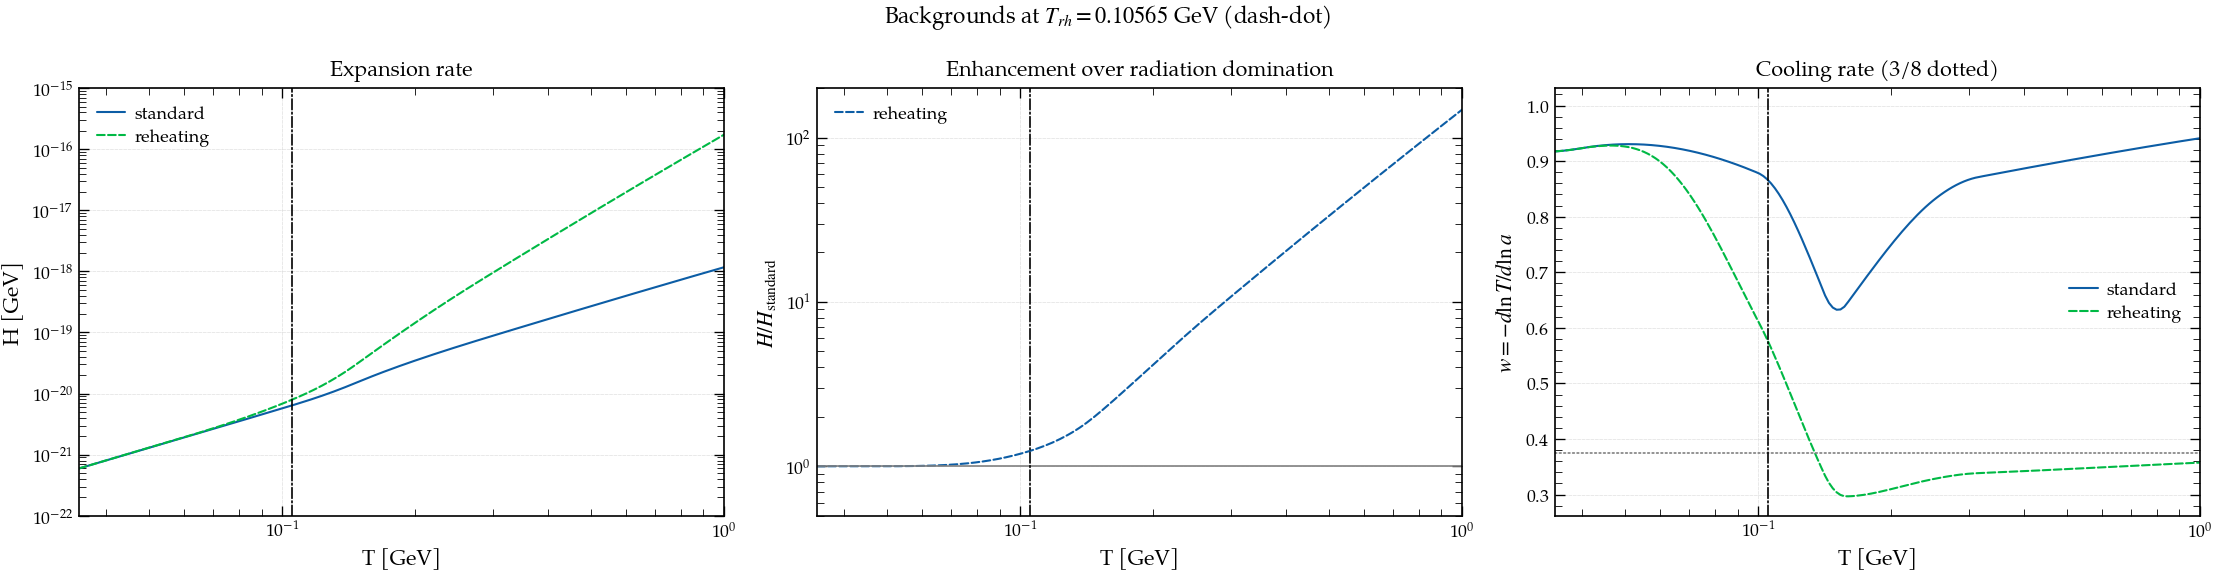

2026-09-14 18:04:40,891 - maxp pruned
2026-09-14 18:04:40,894 - cmap pruned
2026-09-14 18:04:40,895 - post pruned
2026-09-14 18:04:40,895 - FFTM dropped
2026-09-14 18:04:40,897 - GPOS pruned
2026-09-14 18:04:40,898 - GSUB pruned
2026-09-14 18:04:40,904 - glyf pruned
2026-09-14 18:04:40,905 - Added gid0 to subset
2026-09-14 18:04:40,906 - Added first four glyphs to subset
2026-09-14 18:04:40,906 - Closing glyph list over 'GSUB': 19 glyphs before
2026-09-14 18:04:40,906 - Glyph names: ['.notdef', '.null', 'a', 'd', 'equal', 'five', 'l', 'minus', 'n', 'nonmarkingreturn', 'one', 'period', 'r', 's', 'six', 'slash', 'space', 't', 'zero']
2026-09-14 18:04:40,907 - Glyph IDs:   [0, 1, 2, 3, 17, 18, 19, 20, 24, 25, 32, 68, 71, 79, 81, 85, 86, 87, 1061]
2026-09-14 18:04:40,908 - Closed glyph list over 'GSUB': 19 glyphs after
2026-09-14 18:04:40,908 - Glyph names: ['.notdef', '.null', 'a', 'd', 'equal', 'five', 'l', 'minus', 'n', 'nonmarkingreturn', 'one', 'period', 'r', 's', 'six', 'slash', 'spa

['reheating_background.pdf', 'reheating_background.png']

In [35]:
T_RH_SHOWN = M_MU  # GeV
print(T_RH_SHOWN*0.4)

std = StandardCosmology()
sud = SuddenDecayReheating(T_rh=T_RH_SHOWN, gamma_factor = 3)
reh = PerturbativeReheating(T_rh=T_RH_SHOWN, T_start=T_START, gamma_factor = 3)

# Stay inside the range the numerical background integrated.
T = np.logspace(np.log10(reh.T_range[0] * 1.01), np.log10(T_START), 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].loglog(T, std.H(T), label="standard")
# axes[0].loglog(T, sud.H(T), label="sudden")
axes[0].loglog(T, reh.H(T), "--", label="reheating")
axes[0].set_xlabel("T [GeV]")
axes[0].set_ylabel("H [GeV]")
axes[0].set_title("Expansion rate")
axes[0].set_ylim(1e-22, 1e-15)

# axes[1].loglog(T, sud.H(T) / std.H(T), label="sudden")
axes[1].loglog(T, reh.H(T) / std.H(T), "--", label="reheating")
axes[1].axhline(1.0, color="grey", lw=0.8)
axes[1].set_xlabel("T [GeV]")
axes[1].set_ylabel(r"$H / H_{\rm standard}$")
axes[1].set_title("Enhancement over radiation domination")
axes[1].set_ylim(0.5, 200.0) 

axes[2].semilogx(T, std.w(T), label="standard")
# axes[2].semilogx(T, sud.w(T), label="sudden")
axes[2].semilogx(T, reh.w(T), "--", label="reheating")
axes[2].axhline(3.0 / 8.0, color="grey", lw=0.8, ls=":")
axes[2].set_xlabel("T [GeV]")
axes[2].set_ylabel(r"$w = -d\ln T / d\ln a$")
axes[2].set_title("Cooling rate (3/8 dotted)")

for ax in axes:
    ax.axvline(T_RH_SHOWN, color="k", lw=0.8, ls="-.")
    ax.set_xlim(T[0], 1)
    ax.grid(alpha=0.4)
    ax.legend()

fig.suptitle(r"Backgrounds at $T_{{rh}} = {} $ GeV (dash-dot)".format(T_RH_SHOWN))
fig.tight_layout()
plt.show()

fk.save(fig, "reheating_background")

The enhancement reaches $10^6$ by the top of the range, which is the whole point of the
scenario. On that scale the two tiers look identical; the differences live near
$T_{rh}$ and need a zoom.

Note already in the right panel that `sudden` sits flat at exactly $3/8$ above
$T_{rh}$, while `reheating` dips well below it around $T \sim 0.15$ GeV. That is the
QCD transition: entropy dumped out of the quark-gluon dof slows the cooling further,
which the analytic $w = 3/8$ cannot know about. The standard background shows the same
feature, as the dip to $w \approx 0.63$.

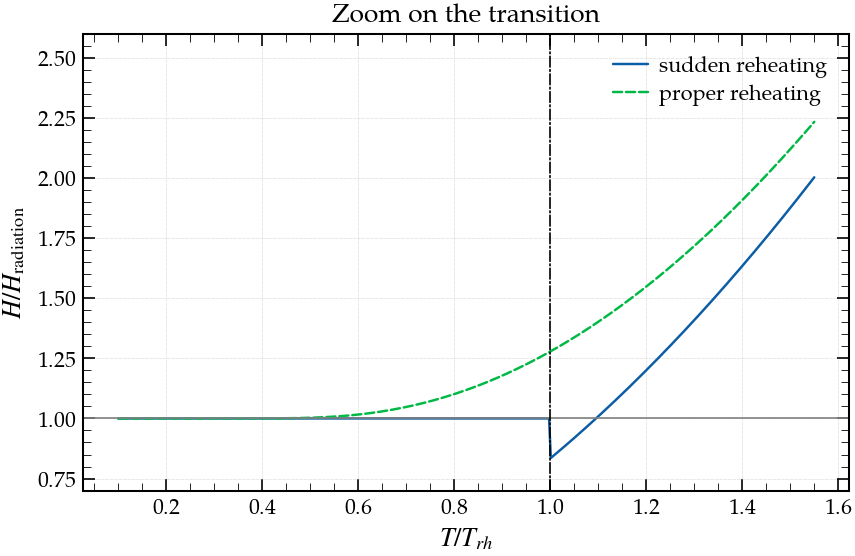

In [29]:
# A tight window: the T^4 growth swamps the step within half a decade.
T_zoom = np.linspace(0.1 * T_RH_SHOWN, 1.55 * T_RH_SHOWN, 400)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_zoom / T_RH_SHOWN, sud.H(T_zoom) / std.H(T_zoom), label="sudden reheating")
ax.plot(T_zoom / T_RH_SHOWN, reh.H(T_zoom) / std.H(T_zoom), "--", label="proper reheating")
ax.axhline(1.0, color="grey", lw=0.8)
# ax.axhline(5.0 / 6.0, color="red", lw=0.8, ls=":", label="5/6")
ax.axvline(1.0, color="k", lw=0.8, ls="-.")
ax.set_xlabel(r"$T / T_{rh}$")
ax.set_ylabel(r"$H / H_{\rm radiation}$")
ax.set_ylim(0.7, 2.6)
ax.set_title("Zoom on the transition")
ax.grid(alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

Now the artefact of the cheap background is visible: `sudden` drops discontinuously to
exactly $5/6$ the moment it crosses $T_{rh}$, so its expansion is briefly *slower* than
radiation domination before the $T^4$ growth takes over. That happens because
$\Gamma = 3 H_{rad}(T_{rh})$ is a convention, not a matching condition — the step is
$5/6$ regardless of $T_{rh}$ or $g_\rho$. `reheating` crosses smoothly. (The matching condition is $\Gamma = 2.5 H_{rad}(T_{rh})$ if you want to have continous $H$ evolution.)

The other difference is on the left of the dash-dot line. `sudden` is *exactly*
radiation domination below $T_{rh}$, by construction. `reheating` is still about 10%
faster there, because the inflaton does not stop decaying at $T_{rh}$ — that
temperature is just where $\Gamma$ was defined. The residual energy takes another
e-fold or so to drain away, and the numerical background carries it.

Two consequences feed the Boltzmann equations, and they are worth separating because
they act on different things.

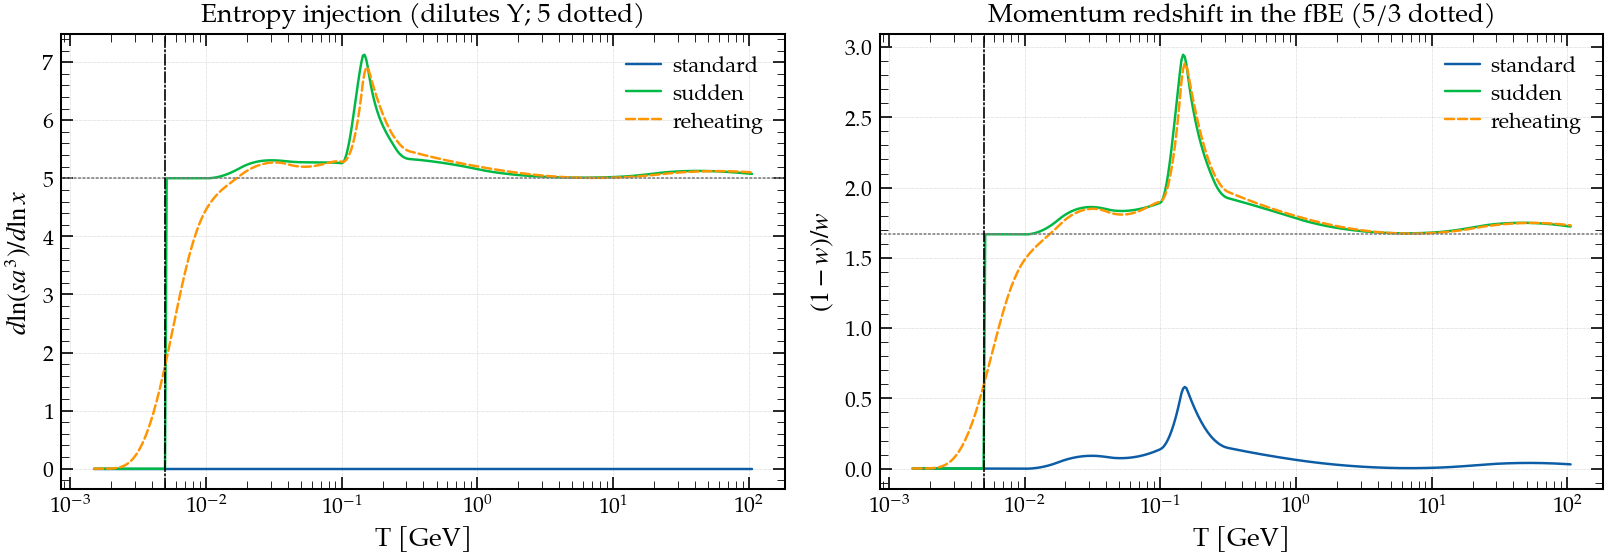

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogx(T, std.dln_sa3_dlnx(T), label="standard")
axes[0].semilogx(T, sud.dln_sa3_dlnx(T), label="sudden")
axes[0].semilogx(T, reh.dln_sa3_dlnx(T), "--", label="reheating")
axes[0].axhline(5.0, color="grey", lw=0.8, ls=":")
axes[0].set_ylabel(r"$d\ln(s a^3) / d\ln x$")
axes[0].set_title("Entropy injection (dilutes Y; 5 dotted)")

axes[1].semilogx(T, std.redshift_coeff(T), label="standard")
axes[1].semilogx(T, sud.redshift_coeff(T), label="sudden")
axes[1].semilogx(T, reh.redshift_coeff(T), "--", label="reheating")
axes[1].axhline(5.0 / 3.0, color="grey", lw=0.8, ls=":")
axes[1].set_ylabel(r"$(1-w)/w$")
axes[1].set_title("Momentum redshift in the fBE (5/3 dotted)")

for ax in axes:
    ax.axvline(T_RH_SHOWN, color="k", lw=0.8, ls="-.")
    ax.set_xlabel("T [GeV]")
    ax.grid(alpha=0.4)
    ax.legend()

fig.tight_layout()
plt.show()

**Left: entropy injection.** Zero on the standard background by construction, and $5$
during reheating ($3/w - 3$ with $w=3/8$). This is a pure dilution of $Y = n/s$: it
suppresses the yield without touching the spectral shape.

**Right: the momentum-redshift coefficient** $(1-w)/w$, which multiplies
$(q\,\partial_q f - 2f)$ in the phase-space equation. Normally this is $\tilde g$,
a small number between $0$ and $\sim0.3$, so $q = p/T$ is very nearly frozen: $p$ and
$T$ both fall as $a^{-1}$ and the ratio does not move. During reheating the coefficient
is $5/3$ — larger by an order of magnitude — because $T$ falls more slowly than
$a^{-1}$, so momenta fall *relative to the bath* and each mode's $q$ is dragged down.

So the two effects act on different things: dilution changes the normalisation of $Y$,
while the redshift term is the only one that can change the shape of $f(q)$. Sections 2
and 3 look at them in turn — though section 3 shows that the shape is not decided by
this term alone.

## 1b. What `T_max` does, and what it does not

$T_{rh}$ does not fix the highest temperature the bath ever reached. $T_{max}$ is set
by the initial inflaton density, so it is an independent input of the scenario.
`PerturbativeReheating` takes it explicitly and refuses to start a run above it.

It is a **guard rather than a knob**. $H(T)$ on the falling branch is fixed by $\Gamma$
alone and does not depend on the initial inflaton density, so supplying $T_{max}$ moves
the answer by parts in a million. What it prevents is a silent contradiction: a run at
`--ratio 1000` starts at $105.65$ GeV, which in a scenario with $T_{max} = 30$ GeV
describes a universe that never existed.

When it becomes a real input is decided by $T_{max}/T_{rh}$ — *not* by $T_{rh}/m_\mu$.
Entropy injection erases its own history: dilution runs at $d\ln(sa^3)/d\ln x = 5$, so a
population made $\Delta$ e-folds before reheating ends is suppressed by $e^{-5\Delta}$.
Everything that survives is produced within a factor of roughly $2.5$ in temperature of
$T_{rh}$. Production higher up is real — at $T_{rh} = 0.03$ GeV the gradual treatment
gives $3.5\times$ the instantaneous yield, so most of the relic *is* made above
$T_{rh}$ — but it is made just above it, in a narrow window.

Measured at $T_{rh} = 0.03$ GeV, i.e. well below $m_\mu$, with $T_{max} = T_{start}$:

| $T_{max}$ [GeV] | $T_{max}/T_{rh}$ | $Y / Y_{\rm converged}$ |
|---|---|---|
| 105.65 ... 0.3 | 3500 ... 10 | 1.0000 |
| 0.1 | 3.3 | 0.9979 |
| 0.05 | 1.7 | 0.8704 |

The cells below leave $T_{max}$ unset, which assumes the attractor reaches as high as
each run begins. By the table above that is safe for every $T_{rh}$ shown here; it would
only need stating for scenarios where reheating barely got going, with $T_{max}$ within
a factor of two of $T_{rh}$.

The same argument is why the rising-$T$ branch is out of scope. Skipping it is forced
by the solver — $x = m/T$ is double-valued across $T_{max}$, so representing it needs
both solvers rewritten in $\ln a$ — but it also costs nothing: that branch lies earlier
than any start point in the table, with a larger $H$ and more dilution still, and the
answer is already converged well below it.

## 2. Yields

The number-density equation is cheap, so this scans $T_{rh}$ properly. The effect is
set by where $T_{rh}$ sits relative to the production epoch, which for a muon run peaks
near $T \sim m_\mu = 0.106$ GeV.

In [28]:
def solve_yield(background):
    '''Final comoving abundance Y from the number-density equation.'''
    x = np.linspace(M_MU / T_START, 30.0, 500)
    q = np.linspace(1e-2, 20.0, 250)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, q)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)

    Y = model.solve_nBE(x, lambda x_, Y_: ann.rate(x_, Y_) + pri.rate(x_, Y_), 0.0)
    return Y[-1]


T_RH_SCAN = np.array([50.0, 10.0, 3.0, 1.0, 0.3, 0.1, 0.03, 0.01, 0.006])

Y_std = solve_yield(std)
Y_sud = np.array([solve_yield(SuddenDecayReheating(T_rh=t)) for t in T_RH_SCAN])
Y_reh = np.array([
    solve_yield(PerturbativeReheating(T_rh=t, T_start=T_START)) for t in T_RH_SCAN
])

print("standard RD:  Y = {:.5e}".format(Y_std))

2026-09-14 17:56:36,963 - Starting solve_nBE...
/mnt/e/Workplace/_Projects/project_axions/PyBolt/PyBolt/cosmology.py:106: RuntimeWarning: overflow encountered in exp
  integral, _ = quad(lambda t: np.sqrt(t**2 - x**2)*t/(np.exp(t)+1.0),x,np.inf)
2026-09-14 17:56:37,819 - solve_nBE completed in 0.86 seconds
2026-09-14 17:56:37,821 - Starting solve_nBE...
2026-09-14 17:56:38,822 - solve_nBE completed in 1.00 seconds
2026-09-14 17:56:38,822 - Starting solve_nBE...
2026-09-14 17:56:39,823 - Progress: 3.145622086447651/30.0, 10.48% - Elapsed time: 1.00 seconds
2026-09-14 17:56:39,971 - solve_nBE completed in 1.15 seconds
2026-09-14 17:56:39,972 - Starting solve_nBE...


KeyboardInterrupt: 

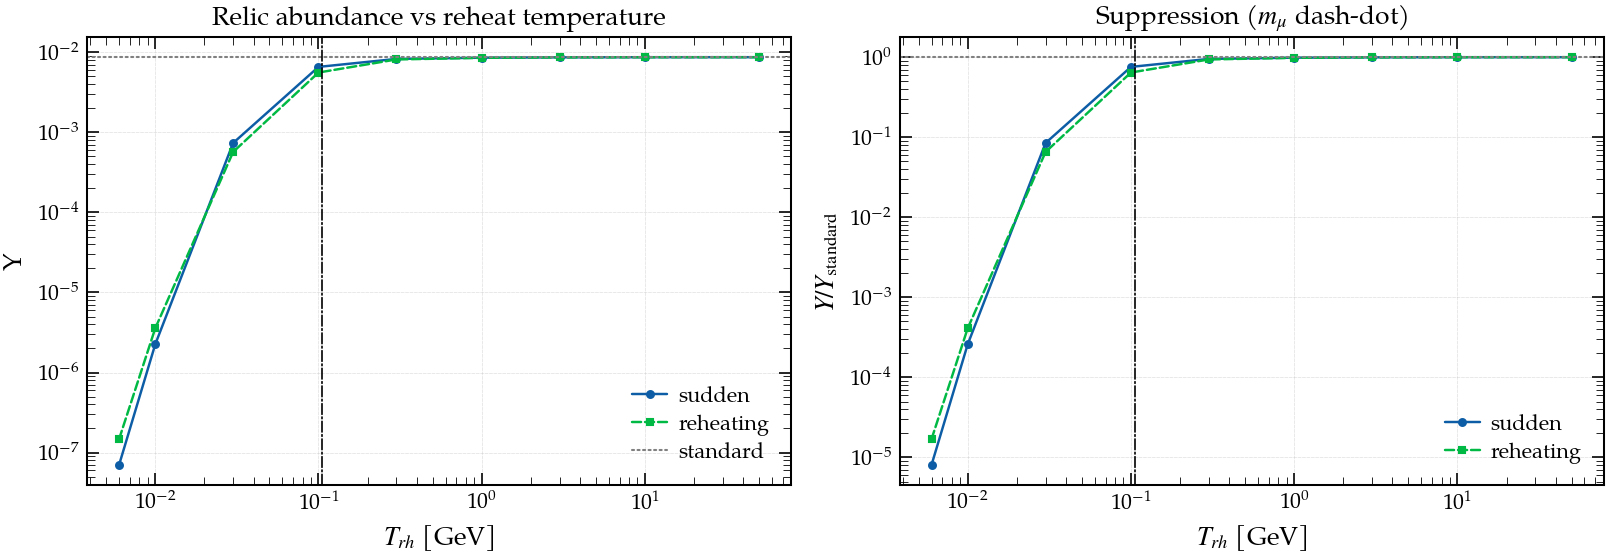

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(T_RH_SCAN, Y_sud, "o-", label="sudden")
axes[0].loglog(T_RH_SCAN, Y_reh, "s--", label="reheating")
axes[0].axhline(Y_std, color="grey", lw=1.0, ls=":", label="standard")
axes[0].axvline(M_MU, color="k", lw=0.8, ls="-.")
axes[0].set_ylabel("Y")
axes[0].set_title("Relic abundance vs reheat temperature")

axes[1].semilogx(T_RH_SCAN, Y_sud / Y_std, "o-", label="sudden")
axes[1].semilogx(T_RH_SCAN, Y_reh / Y_std, "s--", label="reheating")
axes[1].axhline(1.0, color="grey", lw=1.0, ls=":")
axes[1].axvline(M_MU, color="k", lw=0.8, ls="-.")
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$Y / Y_{\rm standard}$")
axes[1].set_title(r"Suppression ($m_\mu$ dash-dot)")

for ax in axes:
    ax.set_xlabel(r"$T_{rh}$ [GeV]")
    ax.grid(alpha=0.4)
    ax.legend()

fig.tight_layout()
plt.show()

In [ ]:
print("{:>10} {:>14} {:>14} {:>10} {:>10} {:>10}".format(
    "T_rh[GeV]", "Y_sudden", "Y_reheating", "sud/std", "reh/std", "sud/reh"))
for t, ys, yr in zip(T_RH_SCAN, Y_sud, Y_reh):
    print("{:>10} {:>14.5e} {:>14.5e} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        t, ys, yr, ys / Y_std, yr / Y_std, ys / yr))

 T_rh[GeV]       Y_sudden    Y_reheating    sud/std    reh/std    sud/reh
      50.0    8.68319e-03    8.68317e-03     1.0000     1.0000     1.0000
      10.0    8.68015e-03    8.67529e-03     0.9997     0.9991     1.0006
       3.0    8.64488e-03    8.63134e-03     0.9956     0.9940     1.0016
       1.0    8.56379e-03    8.52783e-03     0.9863     0.9821     1.0042
       0.3    8.26459e-03    8.13521e-03     0.9518     0.9369     1.0159
       0.1    6.56835e-03    5.58721e-03     0.7564     0.6435     1.1756
      0.03    7.36245e-04    5.68902e-04     0.0848     0.0655     1.2942
      0.01    2.25235e-06    3.57090e-06     0.0003     0.0004     0.6308
     0.006    6.99376e-08    1.46889e-07     0.0000     0.0000     0.4761


Nothing moves while $T_{rh}$ is well above $m_\mu$: reheating is over before the axions
are made. Once $T_{rh}$ drops into the production epoch the yield collapses, by four
orders of magnitude by the time $T_{rh}$ reaches the BBN floor near 5 MeV.

The last column is the one to watch. The cheap background is good to a fraction of a
percent while the effect is small, and wrong by tens of percent exactly where the
effect is large — and the sign of its error flips. Use `sudden` to find the interesting
region and `reheating` to quote a number.

## 2b. Against instantaneous reheating

Section 2 compares against a universe with no reheating era at all, starting at
$T_{start} = 105.65$ GeV. That isolates what the background does, but it is not the
comparison most of the literature makes.

The usual treatment is **instantaneous reheating**: assume the universe is simply
radiation dominated from $T_{rh}$ downwards, with an empty axion population at
$T_{rh}$ and nothing before it. PyBolt has always been able to do this, and needs no
new code — it is exactly a standard-background run whose integration *starts* at
$T_{rh}$. That is what the old `T_reh` name meant.

So the honest question is: at the **same** $T_{rh}$, how good is instantaneous?

In [ ]:
def instantaneous_yield(T_rh):
    '''Old picture: RD from T_rh down, empty at T_rh, nothing before.'''
    return solve_yield_from(StandardCosmology(), T_rh)


def solve_yield_from(background, T_begin):
    '''Final Y for a run that starts at T_begin rather than at T_START.'''
    x = np.linspace(M_MU / T_begin, 30.0, 500)
    q = np.linspace(1e-2, 20.0, 250)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, q)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)
    return model.solve_nBE(
        x, lambda x_, Y_: ann.rate(x_, Y_) + pri.rate(x_, Y_), 0.0)[-1]


T_RH_CMP = np.array([3.0, 1.0, 0.3, 0.1, 0.03, 0.01])

Y_inst = np.array([instantaneous_yield(t) for t in T_RH_CMP])
Y_sud_c = np.array([
    solve_yield_from(SuddenDecayReheating(T_rh=t), T_START) for t in T_RH_CMP])
Y_reh_c = np.array([
    solve_yield_from(PerturbativeReheating(T_rh=t, T_start=T_START), T_START)
    for t in T_RH_CMP])

print("{:>9} {:>9} {:>13} {:>13} {:>10} {:>10}".format(
    "T_rh", "x_start", "Y_instant", "Y_reheating", "sud/inst", "reh/inst"))
for t, yi, ys, yr in zip(T_RH_CMP, Y_inst, Y_sud_c, Y_reh_c):
    print("{:>9} {:>9.3f} {:>13.5e} {:>13.5e} {:>10.4f} {:>10.4f}".format(
        t, M_MU / t, yi, yr, ys / yi, yr / yi))

2026-09-14 13:40:12,508 - Starting solve_nBE...
2026-09-14 13:40:13,256 - solve_nBE completed in 0.75 seconds
2026-09-14 13:40:13,257 - Starting solve_nBE...
2026-09-14 13:40:14,019 - solve_nBE completed in 0.76 seconds
2026-09-14 13:40:14,021 - Starting solve_nBE...
2026-09-14 13:40:14,722 - solve_nBE completed in 0.70 seconds
2026-09-14 13:40:14,723 - Starting solve_nBE...
2026-09-14 13:40:15,170 - solve_nBE completed in 0.45 seconds
2026-09-14 13:40:15,171 - Starting solve_nBE...
2026-09-14 13:40:15,353 - solve_nBE completed in 0.18 seconds
2026-09-14 13:40:15,354 - Starting solve_nBE...
2026-09-14 13:40:15,411 - solve_nBE completed in 0.06 seconds
2026-09-14 13:40:15,412 - Starting solve_nBE...
2026-09-14 13:40:16,413 - Progress: 2.8332758480727582/30.0, 9.44% - Elapsed time: 1.00 seconds
2026-09-14 13:40:16,592 - solve_nBE completed in 1.18 seconds
2026-09-14 13:40:16,593 - Starting solve_nBE...
2026-09-14 13:40:17,593 - Progress: 1.6491888518188507/30.0, 5.49% - Elapsed time: 1.0

     T_rh   x_start     Y_instant   Y_reheating   sud/inst   reh/inst
      3.0     0.035   8.61867e-03   8.63134e-03     1.0030     1.0015
      1.0     0.106   8.49455e-03   8.52783e-03     1.0082     1.0039
      0.3     0.352   8.00255e-03   8.13521e-03     1.0327     1.0166
      0.1     1.056   4.60635e-03   5.58721e-03     1.4259     1.2129
     0.03     3.522   1.62525e-04   5.68902e-04     4.5301     3.5004
     0.01    10.565   1.85603e-08   3.57090e-06   121.3528   192.3940


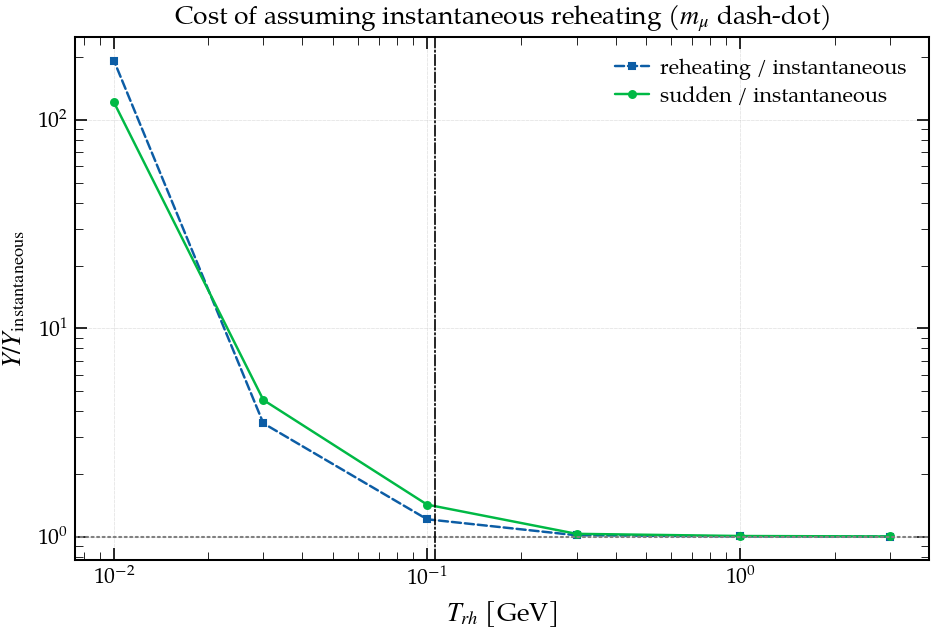

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(T_RH_CMP, Y_reh_c / Y_inst, "s--", label="reheating / instantaneous")
ax.loglog(T_RH_CMP, Y_sud_c / Y_inst, "o-", label="sudden / instantaneous")
ax.axhline(1.0, color="grey", lw=1.0, ls=":")
ax.axvline(M_MU, color="k", lw=0.8, ls="-.")
ax.set_xlabel(r"$T_{rh}$ [GeV]")
ax.set_ylabel(r"$Y / Y_{\rm instantaneous}$")
ax.set_title(r"Cost of assuming instantaneous reheating ($m_\mu$ dash-dot)")
ax.grid(alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()

Instantaneous is fine while $T_{rh}$ is above $m_\mu$, and then fails badly — by a
factor of a few at $T_{rh} = 0.03$ GeV and by **two orders of magnitude** at
$0.01$ GeV. It always errs the same way: it *underestimates*.

The reason is visible in the `x_start` column. Instantaneous reheating at
$T_{rh} = 0.01$ GeV begins the integration at $x = 10.6$, where the muons that source
the axions are Boltzmann suppressed by $e^{-10.6}$ — there is essentially nothing left
to produce from, so the run returns almost zero. The gradual treatment makes its
axions during the reheating era, around $x \sim 1$ where production peaks, at
temperatures well *above* $T_{rh}$, and then dilutes them. Diluted is still far more
than never produced.

Note this flips the sign of the headline depending on what you compare against. Against
a universe with no reheating (section 2), an early matter era **suppresses** the relic
by up to $10^4$. Against instantaneous reheating at the same $T_{rh}$, it **enhances**
it by up to $\sim 200$. Both statements are true, and neither is the whole picture on
its own — the baseline has to be stated.

## 3. Distributions

The phase-space equation is expensive, so this uses a coarser grid than a production
run and caches the results. The physics question is different from the yields: does
reheating change the *shape* of $f(q)$, or only its normalisation?

In [ ]:
CACHE_DIR = "notebook_cache"
CACHE = os.path.join(CACHE_DIR, "distributions.npz")

N_X_FBE, N_Q_FBE = 150, 60
Q_FBE = np.linspace(1e-2, 20.0, N_Q_FBE)

# (label, background) -- solved in this order and stored under these keys.
CASES = [
    ("standard", None),
    ("sudden, T_rh=0.1", ("sudden", 0.1)),
    ("reheating, T_rh=0.1", ("reheating", 0.1)),
    ("sudden, T_rh=0.03", ("sudden", 0.03)),
    ("reheating, T_rh=0.03", ("reheating", 0.03)),
    ("sudden, T_rh=0.005", ("sudden", 0.005)),
    ("reheating, T_rh=0.005", ("reheating", 0.005)),
]


def make_background(spec):
    if spec is None:
        return StandardCosmology()
    kind, t_rh = spec
    if kind == "sudden":
        return SuddenDecayReheating(T_rh=t_rh)
    return PerturbativeReheating(T_rh=t_rh, T_start=T_START)


def solve_distribution(background):
    '''Final f(q) from the full phase-space equation.'''
    x = np.linspace(M_MU / T_START, 30.0, N_X_FBE)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, Q_FBE)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)
    model.addCollisionTerm(ann.collisionTerm)
    model.addCollisionTerm(pri.collisionTerm)

    model.solve_fBE(np.zeros(N_Q_FBE), dict(fBE_LFC.SOLVER_OPTIONS))
    return model.getSolution()[-1, :], model.getDensity()[-1]


# Anything that changes the numbers goes in the key, so editing a grid size can never
# silently reload someone else's results.
CACHE_KEY = np.array([N_X_FBE, N_Q_FBE, F_A, T_START] + [t for _, s in CASES if s
                     for t in [s[1]]], dtype=float)

stored = np.load(CACHE) if os.path.exists(CACHE) else None
if stored is not None and (
    "key" not in stored or not np.array_equal(stored["key"], CACHE_KEY)
):
    print("cache was built with different parameters; recomputing")
    stored = None

if stored is not None:
    f_final = {label: stored[label] for label, _ in CASES}
    Y_fbe = {label: float(stored["Y_" + label]) for label, _ in CASES}
    print("loaded from", CACHE)
else:
    f_final, Y_fbe = {}, {}
    for label, spec in CASES:
        print("solving:", label, flush=True)
        f_final[label], Y_fbe[label] = solve_distribution(make_background(spec))
    os.makedirs(CACHE_DIR, exist_ok=True)
    payload = dict(f_final)
    payload.update({"Y_" + k: np.array(v) for k, v in Y_fbe.items()})
    payload["key"] = CACHE_KEY
    np.savez(CACHE, **payload)
    print("cached to", CACHE)

loaded from notebook_cache/distributions.npz


In [ ]:
# The instantaneous runs start at T_rh rather than at T_START, so they need their own
# solves -- and their own cache, to avoid invalidating the expensive one above.
INSTANT_CACHE = os.path.join(CACHE_DIR, "distributions_instant.npz")
INSTANT_T_RH = [0.1, 0.03]
INSTANT_KEY = np.array([N_X_FBE, N_Q_FBE, F_A] + INSTANT_T_RH, dtype=float)


def solve_distribution_from(background, T_begin):
    '''Final f(q) for a run beginning at T_begin.'''
    x = np.linspace(M_MU / T_begin, 30.0, N_X_FBE)

    model = bz.Model(M_MU, 1e-10, 1.0, "b", background=background)
    model.changeGrid(x, Q_FBE)

    ann = LeptonAnnihilationToAxionMB(M_MU, G_MU, 1.0 / F_A, False)
    pri = PrimakoffScatteringMB(M_MU, G_MU, 1.0 / F_A, False)
    model.addCollisionTerm(ann.collisionTerm)
    model.addCollisionTerm(pri.collisionTerm)

    model.solve_fBE(np.zeros(N_Q_FBE), dict(fBE_LFC.SOLVER_OPTIONS))
    return model.getSolution()[-1, :], model.getDensity()[-1]


INSTANT_LABELS = ["instantaneous, T_rh={}".format(t) for t in INSTANT_T_RH]

cached = np.load(INSTANT_CACHE) if os.path.exists(INSTANT_CACHE) else None
if cached is not None and (
    "key" not in cached or not np.array_equal(cached["key"], INSTANT_KEY)
):
    cached = None

if cached is not None:
    for label in INSTANT_LABELS:
        f_final[label] = cached[label]
        Y_fbe[label] = float(cached["Y_" + label])
    print("loaded from", INSTANT_CACHE)
else:
    payload = {}
    for t_rh, label in zip(INSTANT_T_RH, INSTANT_LABELS):
        print("solving:", label, flush=True)
        f_final[label], Y_fbe[label] = solve_distribution_from(
            StandardCosmology(), t_rh)
        payload[label] = f_final[label]
        payload["Y_" + label] = np.array(Y_fbe[label])
    payload["key"] = INSTANT_KEY
    os.makedirs(CACHE_DIR, exist_ok=True)
    np.savez(INSTANT_CACHE, **payload)
    print("cached to", INSTANT_CACHE)

ALL_LABELS = [label for label, _ in CASES] + INSTANT_LABELS

loaded from notebook_cache/distributions_instant.npz


In [ ]:
import sys, pathlib
from pathlib import Path

FIGKIT_DIR = '/mnt/e/Workplace/HowToMakeAPlot-main/figkit'       # folder containing figkit.py
if str(FIGKIT_DIR) not in sys.path:
    sys.path.insert(0, str(FIGKIT_DIR))


context paper-wide, base 9.0 pt, usetex True
printed size 7.00 x 2.80 in
case                            peak   q_peak     <q>  yield/std
standard                       0.255     1.37    2.37      1.000
sudden, T_rh=0.1              0.1759     1.70    2.62      0.719
reheating, T_rh=0.1           0.1465     1.70    2.64      0.604
sudden, T_rh=0.03            0.01185     2.04    3.23      0.064
reheating, T_rh=0.03         0.01098     1.70    2.84      0.050
sudden, T_rh=0.005         1.402e-06     0.35    0.64      0.000
reheating, T_rh=0.005      2.777e-06     0.35    0.79      0.000
instantaneous, T_rh=0.1       0.1122     2.04    2.99      0.478
instantaneous, T_rh=0.03    0.001882     4.08    4.63      0.012
beyond q = 12: standard 0.0%, sudden 0.0%, reheating 0.0%, sudden 0.1%, reheating 0.1%, sudden 0.0%, reheating 0.0%, instantaneous 0.0%, instantaneous 0.3%


['fbe_final.pdf', 'fbe_final.png']

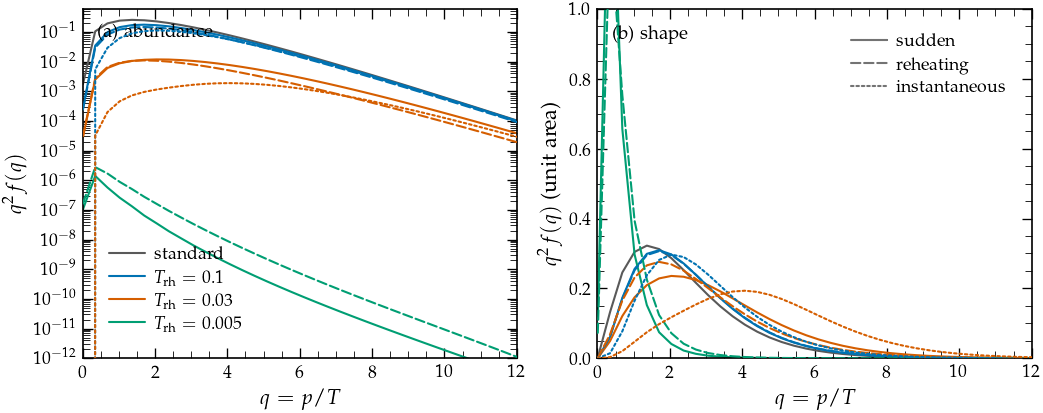

In [ ]:
import sys, re
sys.path.insert(0, r"E:\Workplace\HowToMakeAPlot-main\figkit")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import figkit as fk

DRAFT = False                       # True -> mathtext, fast; False -> real LaTeX
fk.use("paper-wide", font="palatino", usetex=not DRAFT, cycle="cb")

# --- encoding ---------------------------------------------------------------
# colour  = reheating temperature (the thing that changes the answer a lot)
# dashing = how the transition is treated (the thing that changes it a little)
# `standard` is solid like `sudden`, but it is the only grey curve, so colour
# alone identifies it; dotted is spent on `instantaneous`.
KIND_DASH = {"standard": (), "sudden": (), "reheating": (4.5, 1.8),
             "instantaneous": (1.2, 1.4)}
KIND_Z = {"standard": 1, "sudden": 2, "reheating": 3, "instantaneous": 4}
STD_COLOR = "0.35"

def parse(label):
    """('standard'|'sudden'|'reheating'|'instantaneous', T_rh or None)."""
    l = label.strip().lower()
    kind = ("reheating" if l.startswith("reheat") else
            "instantaneous" if l.startswith("instant") else
            "sudden" if l.startswith("sudden") else "standard")
    m = re.search(r"([0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?)\s*$", label)
    return kind, (float(m.group(1)) if m and kind != "standard" else None)

# Hottest T_rh gets blue (closest to standard), coldest gets red.
TRHS = sorted({t for _, t in map(parse, ALL_LABELS) if t is not None},
              reverse=True)
PALETTE = [fk.CB_COLORS[k] for k in ("blue", "red", "green", "purple")]
TRH_COLOR = {t: PALETTE[i % len(PALETTE)] for i, t in enumerate(TRHS)}

area = {lab: np.trapezoid(f_final[lab], Q_FBE) for lab in ALL_LABELS}

# --- figure -----------------------------------------------------------------
fig, (axL, axR) = fk.figure(ncols=2, aspect=0.40, sharex=True)

for label in ALL_LABELS:
    kind, trh = parse(label)
    c = STD_COLOR if trh is None else TRH_COLOR[trh]
    kw = dict(color=c, dashes=KIND_DASH[kind], zorder=KIND_Z[kind])
    axL.plot(Q_FBE, f_final[label], **kw)
    axR.plot(Q_FBE, f_final[label] / area[label], **kw)   # unit area: shape only

# Left: log y, because the coldest T_rh curves are more than a decade down and
# are invisible on a linear axis. Peak heights are printed in the checks cell.
axL.set_yscale("log")
axL.set_ylim(1e-12, 6e-1)
fk.log_minor_ticks(axL, axis="y")
axL.set_ylabel(r"$q^{2} f(q)$")

axR.set_ylim(0, 1.0)
axR.set_ylabel(r"$q^{2} f(q)$ (unit area)")

for ax, tag in ((axL, r"(a) abundance"), (axR, r"(b) shape")):
    ax.set_xlim(0, 12)
    ax.set_xlabel(r"$q = p/T$")
    ax.text(0.035, 0.955, tag, transform=ax.transAxes, ha="left", va="top")

# --- one legend per encoding channel, one per panel -------------------------
h_colour = ([Line2D([], [], color=STD_COLOR, label="standard")] +
            [Line2D([], [], color=TRH_COLOR[t], label=rf"$T_{{\rm rh}}={t:g}$")
             for t in TRHS])
kinds = [k for k in ("sudden", "reheating", "instantaneous")
         if any(parse(l)[0] == k for l in ALL_LABELS)]
h_dash = [Line2D([], [], color="0.45", dashes=KIND_DASH[k] or (1, 0), label=k)
          for k in kinds]

axL.legend(handles=h_colour, loc="lower left", handlelength=2.0,
           bbox_to_anchor=(0.02, 0.02))
axR.legend(handles=h_dash, loc="upper right", handlelength=2.0,
           bbox_to_anchor=(0.98, 0.98))

fk.show(fig)

# ===========================================================================
# Checks
# ===========================================================================
res = fk.current()
print(f"context {res.context}, base {res.base} pt, usetex {res.usetex}")
print(f"printed size {fig.get_size_inches()[0]:.2f} x "
      f"{fig.get_size_inches()[1]:.2f} in")
std = next((l for l in ALL_LABELS if parse(l)[0] == "standard"), ALL_LABELS[0])
print(f"{'case':<26}{'peak':>10}{'q_peak':>9}{'<q>':>8}{'yield/std':>11}")
for label in ALL_LABELS:
    y = f_final[label]
    qm = np.trapezoid(Q_FBE * y, Q_FBE) / area[label]
    print(f"{label:<26}{y.max():>10.4g}{Q_FBE[np.argmax(y)]:>9.2f}"
          f"{qm:>8.2f}{area[label] / area[std]:>11.3f}")
    if y.max() < axL.get_ylim()[0]:
        print(f"  WARNING: {label} peak is below the y-limit")
tail = {l: np.trapezoid(f_final[l][Q_FBE > 12], Q_FBE[Q_FBE > 12]) / area[l]
        for l in ALL_LABELS}
print("beyond q = 12: " + ", ".join(f"{l.split(',')[0]} {v:.1%}"
                                    for l, v in tail.items()))

fk.save(fig, "fbe_final")

In [ ]:
print("{:>22} {:>13} {:>10} {:>9}".format("case", "Y (fBE)", "Y/Y_std", "<q>"))
for label in ALL_LABELS:
    mean_q = (np.trapezoid(Q_FBE * f_final[label], Q_FBE)
              / np.trapezoid(f_final[label], Q_FBE))
    print("{:>22} {:>13.5e} {:>10.4f} {:>9.3f}".format(
        label, Y_fbe[label], Y_fbe[label] / Y_fbe["standard"], mean_q))

                  case       Y (fBE)    Y/Y_std       <q>
              standard   8.50546e-03     1.0000     2.372
      sudden, T_rh=0.1   6.11241e-03     0.7186     2.619
   reheating, T_rh=0.1   5.13659e-03     0.6039     2.638
     sudden, T_rh=0.03   5.40785e-04     0.0636     3.229
  reheating, T_rh=0.03   4.27749e-04     0.0503     2.843
    sudden, T_rh=0.005   9.33155e-09     0.0000     0.643
 reheating, T_rh=0.005   2.40781e-08     0.0000     0.792
instantaneous, T_rh=0.1   4.06622e-03     0.4781     2.990
instantaneous, T_rh=0.03   1.04671e-04     0.0123     4.632


The left panel is dominated by the normalisation collapse already seen in the yields.
The right panel is the interesting one: the spectra under reheating are **harder**,
shifted to *higher* $q$, and $\langle q \rangle$ in the table quantifies it.

That is worth pausing on, because it is the opposite of what the $(1-w)/w = 5/3$ term
does on its own. That term drags each mode's $q$ *down*. The final spectrum is set by
the competition between it and *when* the population is produced, and the production
timing wins:

- Reheating suppresses early production, both through the faster $H$ and through the
  entropy dumped on top of whatever was made. What survives is dominated by axions
  produced *late*.
- Late means $x \gg 1$, where the muons are non-relativistic and the axions come out
  with $p \sim m_\mu/2$, so $q = p/T \sim x/2$ — large and growing.

So the surviving population is weighted towards the hard, late-produced part of the
spectrum, and that outruns the downward drag of the redshift term.

Note also that the two tiers disagree more in shape than in normalisation at
$T_{rh} = 0.03$ GeV: about 13% in $\langle q \rangle$ against 35% in $Y$. If you care
about the spectrum, `sudden` is a worse approximation than the yield plot suggests.

This matters for anything downstream that cares about the spectrum rather than the
number: free-streaming, warmness constraints, and any $\Delta N_{\rm eff}$ estimate
weighted by energy rather than number.

## 4. What to take away

- **Yields** are suppressed once $T_{rh}$ falls into the production epoch, by four
  orders of magnitude near the BBN floor. The mechanism is entropy dilution,
  $d\ln(sa^3)/d\ln x = 5$, plus reduced production against a faster $H$.
- **Distributions** come out *harder*, not softer. The momentum-redshift term grows
  from $\tilde g \lesssim 0.3$ to $5/3$ and drags each mode down, but the shift in
  *when* the surviving population is produced pushes the other way and wins.
- **`sudden` versus `reheating`** agree to a fraction of a percent while the effect is
  small and disagree by tens of percent where it is large, with the sign of the error
  flipping. The cheap background is for scouting, not for numbers -- and it is worse
  for the spectrum than the yield comparison alone would suggest.
- **Instantaneous reheating underestimates**, by a factor of a few at
  $T_{rh} = 0.03$ GeV and about $200$ at $0.01$ GeV, because it starts the integration
  after the muons have already Boltzmann-suppressed away and so never makes the axions
  at all. Resolving the reheating era is not a refinement here, it is the difference
  between a population and nothing.
- **State the baseline.** An early matter era suppresses the relic against a universe
  that never had one, and enhances it against the instantaneous approximation at the
  same $T_{rh}$. The two statements differ by six orders of magnitude and are both
  correct.
- **`T_max` is a guard, not a knob** for everything shown here: the answer is converged
  once $T_{max} \gtrsim 5\,T_{rh}$, and only becomes sensitive when $T_{max}$ falls
  within a factor of two of $T_{rh}$. The criterion is $T_{max}/T_{rh}$, not
  $T_{rh}/m_\mu$, because entropy injection erases production made more than about an
  e-fold before reheating ends.

The remaining approximation on the low-$T_{rh}$ end is that the run starts on the
reheating attractor rather than climbing the rising-temperature branch to $T_{max}$.
That branch would make $x = m/T$ non-monotonic and needs both solvers re-expressed in
$\ln a$.